# ADCP Data Analysis

In [25]:
from mhkit import dolfyn

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.signal import butter, sosfiltfilt
import pandas as pd

import my_functions as my

In [3]:
# loading processed data
ds = dolfyn.load('A0524000_processed.nc')
ds

<xarray.Dataset> Size: 18MB
Dimensions:              (time: 16672, dir: 4, range: 24, beam: 4, x1: 4,
                          x2: 4, earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 133kB 2024-05-15T12:00:00 ... ...
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * range                (range) float32 96B 3.52 4.52 5.52 ... 25.52 26.52
  * beam                 (beam) int32 16B 1 2 3 4
  * x1                   (x1) int64 32B 1 2 3 4
  * x2                   (x2) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/21)
    number               (time) uint32 67kB 193 194 195 ... 16862 16863 16864
    builtin_test_fail    (time) bool 17kB False False False ... False False
    c_sound              (time) float32 67kB 1.507e+03 1.507e+03 ... 1.518e+03
    depth                (time) float32 67kB 22.36 22.36 22.26 ... 23.56 23.66
    pitch                (time) float32 67kB -6.44 -6.44 -6.45 ... -6.7 -6.68
    roll                 (time) float32 67kB -1.2 -1.22 -1.22 ... -1.28 -1.28
    ...                   ...
    vel                  (dir, range, time) float32 6MB 0.2 0.185 ... nan nan
    amp                  (beam, range, time) float32 6MB 141.0 142.0 ... nan nan
    corr                 (beam, range, time) uint8 2MB 123 124 123 ... 104 105
    prcnt_gd             (beam, range, time) uint8 2MB 0 0 0 0 0 0 ... 0 0 0 0 0
    beam2inst_orientmat  (x1, x2) float32 64B 1.462 -1.462 0.0 ... -1.034 -1.034
    orientmat            (earth, inst, time) float32 600kB 0.3437 ... -0.993
Attributes: (12/38)
    firmware_ver:             50.4
    inst_make:                TRDI
    inst_type:                ADCP
    rotate_vars:              ['vel']
    has_imu:                  0
    inst_model:               Workhorse
    ...                       ...
    transmit_lag_m:           0.25
    bandwidth:                0
    power_level:              255
    serialnum:                21788
    range_offset:             1.4
    fs:                       0.0011363636363636363

### Filtering tides, removing surface interference and values above the surface

To avoid overfiltrating due to NaN values, the velocity variable is interpolated to fill in gaps. The NaN values are saved and later reinserted.

In order to filter tides from the velocity, the range coordinate (which vary in time) is normalized and interpolated to a constant interval. The interval is choosen so that surface interference and values above the surface are removed. 

Thereafter, a lowpass filter is applied on velocity and temperature. Data is then reconverted to the original coordinate. 

#### Saving NaNs and filling in gaps

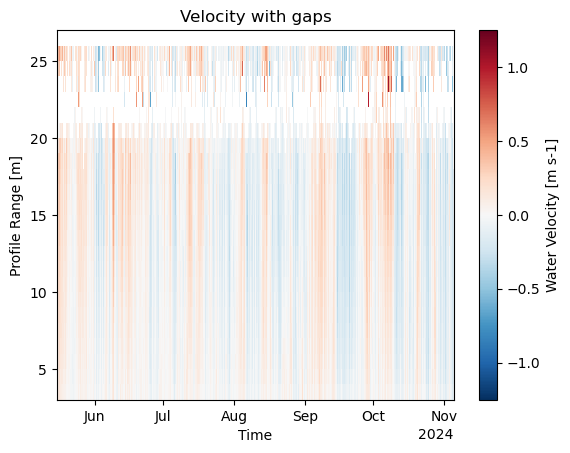

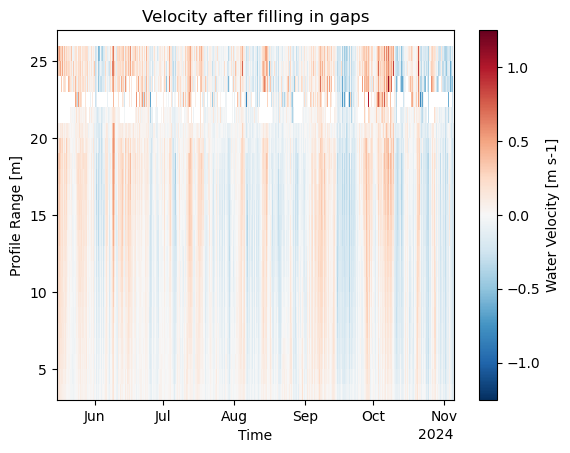

In [4]:
# Save NaNs
mask_nan = np.isnan(ds['vel'])
ds_interp = ds.copy()

ds['vel'][0].plot()
plt.xlabel('Time')
plt.title('Velocity with gaps')
plt.show()

ds_interp['vel'] = ds['vel'].interpolate_na(dim='time', method='linear', max_gap=np.timedelta64(12, 'h'))

ds_interp['vel'][0].plot()
plt.xlabel('Time')
plt.title('Velocity after filling in gaps')
plt.show()

#### Normalizing range and interpolating to constant interval

In [5]:
# Create normalized height coordinate (z/h)
ds_interp = ds_interp.assign_coords(zn = ds_interp['range'] / ds_interp['depth'])

# New normalized height grid to interpolate to
# start at 0.15 corresponds to 3.4 ~ first measurement
# end at 0.85 corresponds to removing upper 15% below surface
# 0.05% spacing corresponds to 1.1 m ~ cell size=1m
zn_new = np.arange(0.15,0.85+0.05,0.05)  

# Apply interpolation to each profile
vel_interp = xr.apply_ufunc(
    my.interp_profile,
    ds_interp['vel'],       # (dir, range, time)
    ds_interp['zn'],        # (range, time)
    kwargs={'coord_new': zn_new},
    input_core_dims=[['range'], ['range']],  
    output_core_dims=[['zn_new']],
    exclude_dims=set(('range',)),
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float],
    dask_gufunc_kwargs={'output_sizes': {'zn_new': len(zn_new)}},
)

# Assign the new coordinate
vel_interp = vel_interp.assign_coords(zn_new=zn_new).transpose('dir', 'zn_new', 'time')
ds_interp['vel_interp'] = vel_interp

#### Filtering

Synthetic tidal signal is used to decide parameters.

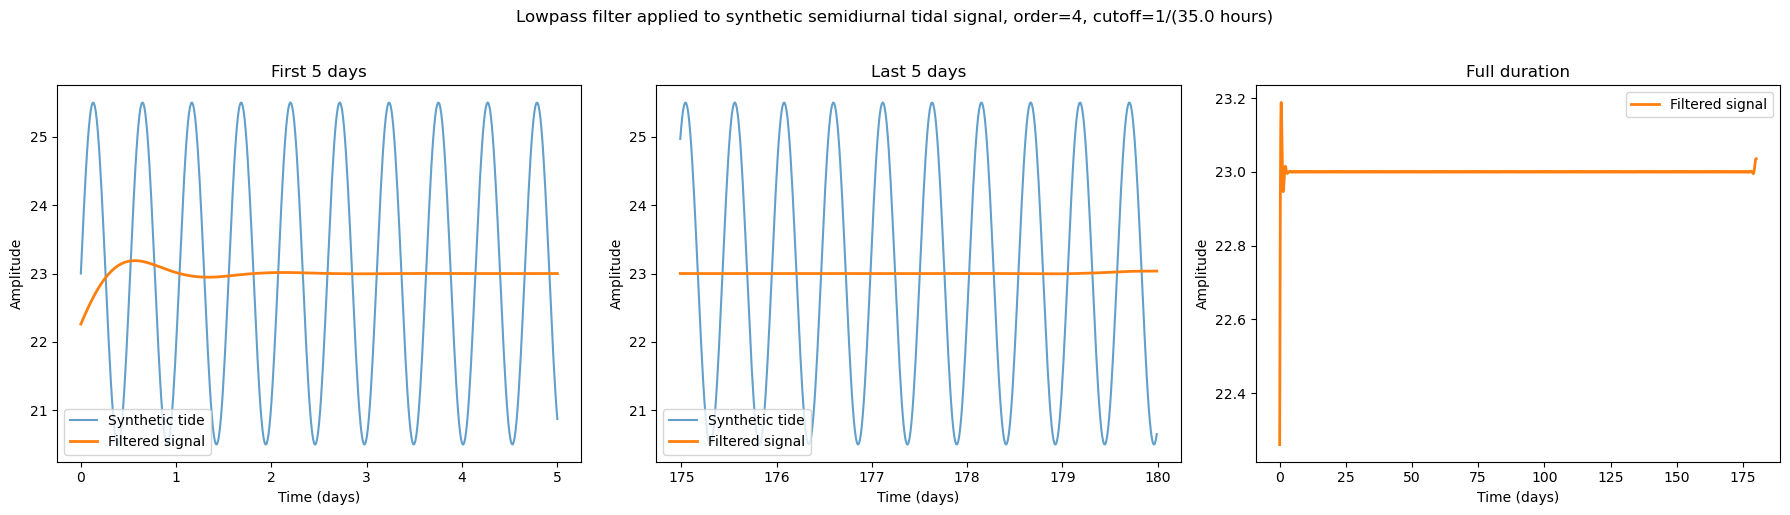

In [6]:
# Filter parameters 
# Cutoff and order are given from filtering synthetic tidal signal.
order = 4                   # choice of how sharply to filter
fs= 1/(15 * 60)             # Sampling rate, data is averaged, time step 15 min
cutoff_period = 35 * 3600   # Tidal frequency cutoff corresponding to period of x hours
cutoff = 1 / cutoff_period  
nyq = 0.5 * fs              # highest detectable frequency
normal_cutoff = cutoff/nyq

# Design filter
sos = butter(order, normal_cutoff, btype='lowpass', output='sos') 

# Synthetic tidal signal
duration = 6 * 30 * 24 * 3600  # 6 months
dt = 15 * 60                   # 15 intervals
t = np.arange(0, duration, dt)
T = 12.42 * 3600        # Semidiurnal tide has period of ~12.42 hours
omega = 2 * np.pi / T   # Angular frequency

tidal_signal = 23 + 2.5 * np.sin(omega * t)

# Apply filter on tidal signal
filtered_signal = sosfiltfilt(sos, tidal_signal)

# Plot tidal signal before and after fitlering
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
t_days = t / (24 * 3600)

# First 5 days
mask_first = t_days <= 5
ax1.plot(t_days[mask_first], tidal_signal[mask_first], label='Synthetic tide', alpha=0.7)
ax1.plot(t_days[mask_first], filtered_signal[mask_first], label='Filtered signal', linewidth=2)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Amplitude')
ax1.set_title('First 5 days')
ax1.legend()

# Last 5 days
mask_last = t_days >= (t_days[-1] - 5)
ax2.plot(t_days[mask_last], tidal_signal[mask_last], label='Synthetic tide', alpha=0.7)
ax2.plot(t_days[mask_last], filtered_signal[mask_last], label='Filtered signal', linewidth=2)
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Amplitude')
ax2.set_title('Last 5 days')
ax2.legend()

# Full duration of filtered signal only
ax3.plot(t_days, filtered_signal, label='Filtered signal', linewidth=2, color='tab:orange')
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('Amplitude')
ax3.set_title('Full duration')
ax3.legend()

plt.suptitle(f'Lowpass filter applied to synthetic semidiurnal tidal signal, order={order}, cutoff=1/({(cutoff_period/3600)} hours)', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Apply the filter on velocity, temperature and pressure
vel_no_tides = sosfiltfilt(sos, ds_interp['vel_interp'])
temp_no_tides = sosfiltfilt(sos, ds_interp['temp'])
pressure_no_tides = sosfiltfilt(sos, ds_interp['pressure'])

# Assign dimensions and coordinates
vel_no_tides = xr.DataArray(
    vel_no_tides,
    dims=('dir', 'zn_new', 'time'),
    coords={
        'dir': ds_interp['dir'],
        'range': ds_interp['zn_new'],
        'time': ds_interp['time']
    },
    name='vel_no_tides'
)

temp_no_tides = xr.DataArray(
    temp_no_tides,
    dims=('time'),
    coords={'time': ds_interp['time']},
    name='temp_no_tides'
)

pressure_no_tides = xr.DataArray(
    pressure_no_tides,
    dims=('time'),
    coords={'time': ds_interp['time']},
    name='pressure_no_tides'
)

ds_filt = ds_interp.copy()
ds_filt['vel_no_tides'] = vel_no_tides
ds_filt['temp_no_tides'] = temp_no_tides
ds_filt['pressure_no_tides'] = pressure_no_tides

#### Reconverting to range and interpolating back

In [8]:
# Reconvert the normalized height in real height (zn_new*h)
ds_filt = ds_filt.assign_coords(
z = ds_filt['zn_new'] * ds_filt['depth'] 
)

# Interpolating back to range coordinate
vel_filt = xr.apply_ufunc(
    my.interp_profile,
    ds_filt['vel_no_tides'],       # (dir, zn_new, time)
    ds_filt['z'],                  # (zn_new)
    kwargs={'coord_new': ds_filt['range'].values},  #target grid: fixed grid
    input_core_dims=[['zn_new'],['zn_new']], 
    output_core_dims=[['range']],
    exclude_dims=set(('zn_new',)),
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float],
    dask_gufunc_kwargs={'output_sizes': {'range': len(ds_filt['range'])}},
)

# Assign the new coordinate
vel_filt = vel_filt.assign_coords(range=ds_filt['range']).transpose('dir', 'range', 'time')

# Save results to  dataset

ds['vel_filt'] = vel_filt
ds['vel_filt'].attrs = {
    'long_name': 'Velocity filtered',
    'units': 'Water Velocity m s-1',
    'description': 'Velocity filtered from tidal flucuations'
}

ds['temp_filt'] = ds_filt['temp_no_tides']
ds['temp_filt'].attrs = {
    'long_name': 'Temperature filtered',
    'units': 'Degree C',
    'description': 'Temperature filtered from tidal flucuations'
}

ds['pressure_filt'] = ds_filt['pressure_no_tides']
ds['pressure_filt'].attrs = {
    'long_name': 'Pressure filtered',
    'units': 'dBar',
    'description': 'Pressure filtered from tidal flucuations'
}

#### Reinserting NaNs and discarding data due to side effect from filtering


In [9]:
# Reinserting NaNs from before gaps were filled in
nan_before = np.isnan(ds['vel_filt']).values.sum()
print('NaN values in ds.vel_filt before reinserting NaNs:', nan_before)
ds['vel_filt'] = ds['vel_filt'].where(~mask_nan, other=np.nan)
nan_after = np.isnan(ds['vel_filt']).values.sum()
print('Added NaN values in ds.vel_filt by reinserting NaNs:', nan_after-nan_before)

# Discarding data due to side effect from filtering
ds['vel_filt'] = ds['vel_filt'].where(ds['time']>np.datetime64('2024-05-16T12:00:00'), other=np.nan)
print('Added NaN values in ds.vel_filt by discarding data:', np.isnan(ds['vel_filt']).values.sum()-nan_after)

print('Total NaN values:', np.isnan(ds['vel_filt']).values.sum())



NaN values in ds.vel_filt before reinserting NaNs: 623556
Added NaN values in ds.vel_filt by reinserting NaNs: 696
Added NaN values in ds.vel_filt by discarding data: 5676
Total NaN values: 629928


#### Results from filtering, removing surface interference and values above the surface.

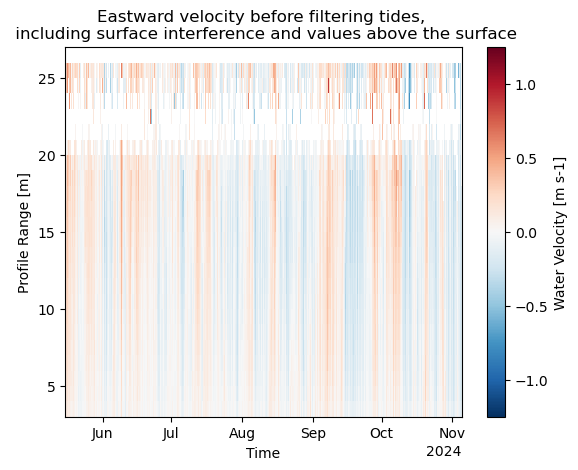

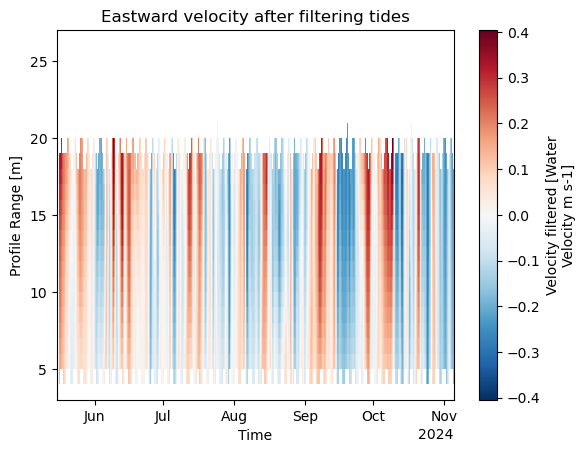

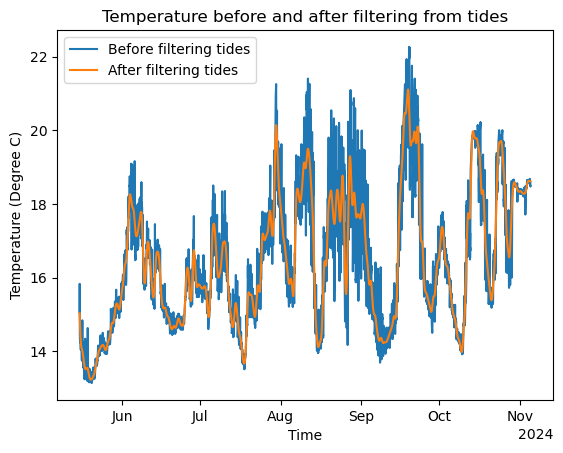

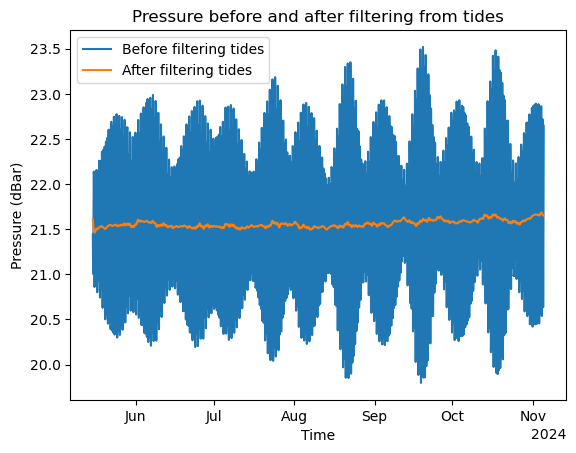

In [10]:
ds['vel'][0].plot()
plt.xlabel('Time')
plt.title('Eastward velocity before filtering tides, \n including surface interference and values above the surface')
plt.show()

ds['vel_filt'][0].plot()
plt.xlabel('Time')
plt.title('Eastward velocity after filtering tides')
plt.show()

ds['temp'].plot(label='Before filtering tides')
ds['temp_filt'].plot(label='After filtering tides')
plt.xlabel('Time')
plt.ylabel('Temperature (Degree C)')
plt.legend()
plt.title('Temperature before and after filtering from tides')
plt.show()

ds['pressure'].plot(label='Before filtering tides')
ds['pressure_filt'].plot(label='After filtering tides')
plt.xlabel('Time')
plt.ylabel('Pressure (dBar)')
plt.legend()
plt.title('Pressure before and after filtering from tides')
plt.show()

### Filling in gaps where there is enough data

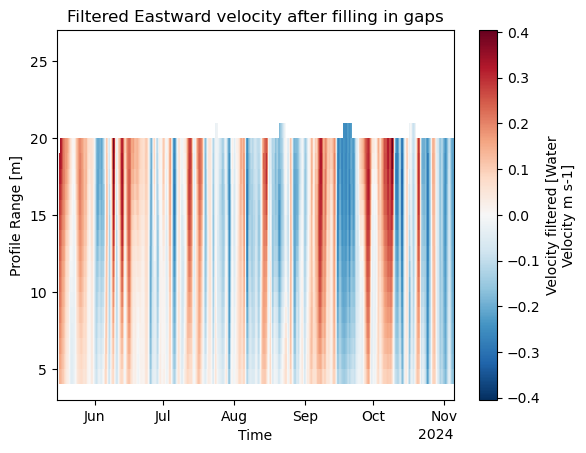

In [11]:
ds['vel_interp'] = ds['vel_filt'].interpolate_na(dim='time', method='linear', max_gap=np.timedelta64(2*24, 'h'))

ds['vel_interp'][0].plot()
plt.xlabel('Time')
plt.title('Filtered Eastward velocity after filling in gaps')
plt.show()

### Rotating velocity directions to alongshore and cross-shore

Principal heading = 56.3999


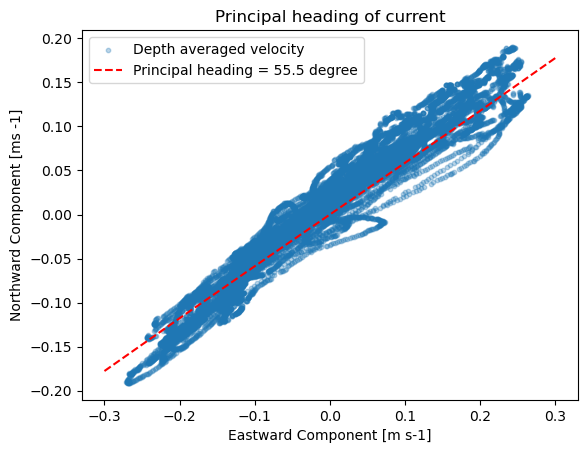

In [12]:
# Average velocity along water column
ds['vel_avg'] = ds['vel_filt'].mean(dim='range')

ds.attrs["principal_heading"] = dolfyn.calc_principal_heading(ds['vel_avg'])
princp_heading = ds.attrs["principal_heading"] # calculates principal heading using depth averaged velocity
print(f'Principal heading = {princp_heading}')

range_values = np.arange(-0.3, 0.4, 0.1)

plt.scatter(ds['vel_avg'][0],ds['vel_avg'][1], label='Depth averaged velocity', s=10, alpha=0.3)
plt.plot(range_values, np.tan(np.deg2rad(90-princp_heading)*range_values), 'r', linestyle='--', label='Principal heading = 55.5 degree')
plt.title('Principal heading of current')
plt.xlabel('Eastward Component [m s-1]')
plt.ylabel('Northward Component [ms -1]')
plt.legend()

ds.attrs['rotate_vars'] = ['vel', 'vel_filt', 'vel_avg'] # add filtered and averaged velocities to be rotated too
ds_2 = dolfyn.rotate2(ds, "principal", inplace=False) # rotate acording to principal heading

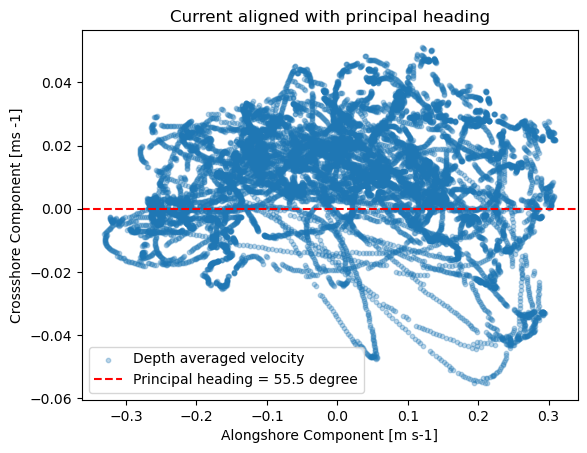

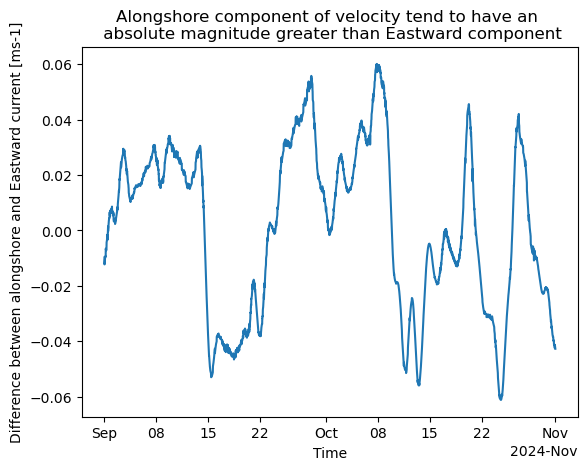

In [15]:
range_values2 = np.arange(-0.3, 0.3, 0.1)
plt.scatter(ds_2['vel_avg'][0],ds_2['vel_avg'][1], label='Depth averaged velocity', s=10, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', label='Principal heading = 55.5 degree')
plt.title('Current aligned with principal heading')
plt.xlabel('Alongshore Component [m s-1]')
plt.ylabel('Crossshore Component [ms -1]')
plt.legend()
plt.show()


# Select time range
time_slice = slice('2024-09', '2024-10')

vel_diff = ds_2['vel_avg'][0]- ds['vel_avg'][0]
vel_diff.sel(time=time_slice).plot()
plt.ylabel('Difference between alongshore and Eastward current [ms-1]')
plt.title('Alongshore component of velocity tend to have an \n absolute magnitude greater than Eastward component')
plt.show()



### Comparing alongshore current with temperature

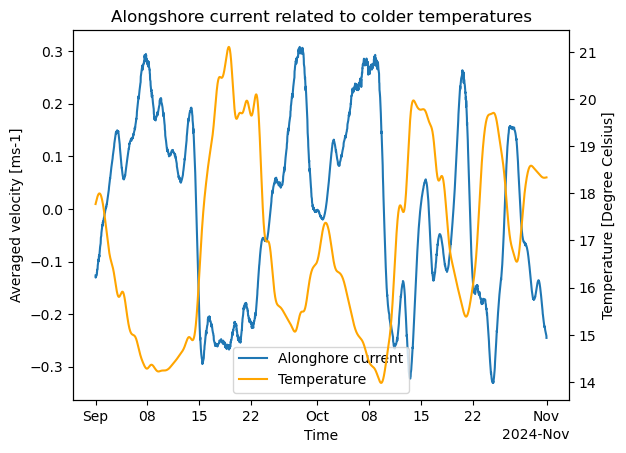

In [ ]:
fig, ax1 = plt.subplots()
# Plot vel_avg on the left axis
ds_2['vel_avg'][0].sel(time=time_slice).plot(ax=ax1, label='Alonghore current')
ax1.set_ylabel('Averaged velocity [ms-1]')
ax1.set_title('Alongshore current related to colder temperatures')

# Create a twin axis for temp_filt
ax2 = ax1.twinx()
ds_2['temp_filt'].sel(time=time_slice).plot(ax=ax2, color='orange', label='Temperature')
ax2.set_ylabel('Temperature [Degree Celsius]')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()

### Summary of results

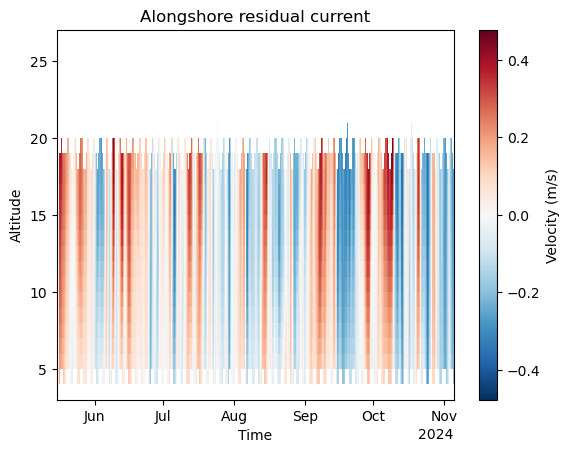

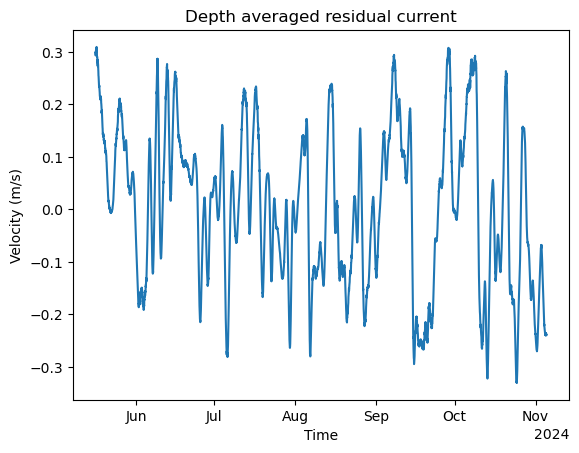

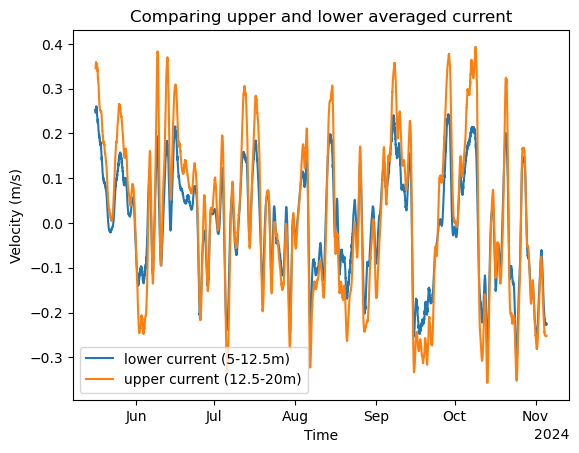

In [78]:
ds_2['vel_filt'][0].plot(cbar_kwargs={'label': 'Velocity (m/s)'})
plt.xlabel('Time')
plt.ylabel('Altitude')
plt.title('Alongshore residual current')
plt.show()

ds_2['vel_avg'][0].plot()
plt.title('Depth averaged residual current')
plt.ylabel('Velocity (m/s)')
plt.show()

ds_2['vel_lower'] = ds_2['vel_filt'].sel(range=slice(0, 12.5)).mean(dim='range').rename('vel_lower')
ds_2['vel_upper'] = ds_2['vel_filt'].sel(range=slice(12.5, 20)).mean(dim='range').rename('vel_upper')

ds_2['vel_lower'][0].plot(label='lower current (5-12.5m)')
ds_2['vel_upper'][0].plot(label='upper current (12.5-20m)')
plt.ylabel('Velocity (m/s)')
plt.legend()
plt.title('Comparing upper and lower averaged current')
plt.show()


### Exporting as dataframe

In [93]:
vel_filt = ds_2['vel_filt'][0].drop_vars('dir')
df_vel = vel_filt.to_dataframe().reset_index()
print(df_vel.head())

vel_avg = ds_2['vel_avg'][0]
vel_lower = ds_2['vel_lower'][0]
vel_upper = ds_2['vel_upper'][0]

df_avg = pd.DataFrame({
    'time': vel_lower.time.values,
    'vel_lower': vel_lower.values,
    'vel_upper': vel_upper.values,
    'vel_avg': vel_avg.values
})

print(df_avg.head())

df_vel.to_csv("df_vel.csv", index=True)
df_avg.to_csv("df_avg.csv", index=True)

   range                time  vel_filt
0   3.52 2024-05-15 12:00:00       NaN
1   3.52 2024-05-15 12:15:00       NaN
2   3.52 2024-05-15 12:30:00       NaN
3   3.52 2024-05-15 12:45:00       NaN
4   3.52 2024-05-15 13:00:00       NaN
                 time  vel_lower  vel_upper  vel_avg
0 2024-05-15 12:00:00        NaN        NaN      NaN
1 2024-05-15 12:15:00        NaN        NaN      NaN
2 2024-05-15 12:30:00        NaN        NaN      NaN
3 2024-05-15 12:45:00        NaN        NaN      NaN
4 2024-05-15 13:00:00        NaN        NaN      NaN
